# Time Series and Stock Market Data with yfinance

**Applied Data Science  |  MBA 2027  |  Session 5 Lab Exercise**

---

| | |
|---|---|
| **Name** | *(Aurangzaib Gill)* |
| **Roll number** | *(27010005)* |
| **Date** | *(9/18/2026)* |
| **AI tool used** | *(Google search & Claude (G))* |

---

### What this lab is for

This lab is the practice run for your **Stock Lab assignment** (the comparative analysis of
Microsoft, Apple and Nvidia). Everything you need for that assignment, you will learn here on a
shorter and safer date range.

The assignment asks what \$10,000 invested on 1 January 2000 would be worth on 31 December
2024. There are at least four ways to get a wrong number for that, and every one of them
produces an answer that looks perfectly reasonable. By the end of this lab you should know all
four.

### How to submit

1. Work through every part in order. Do not delete any cell.
2. Where a cell says **Your answer**, type into it. Where it says **Your code**, write code and run it.
3. When finished: **File > Download > Download .ipynb**, rename to
   `S5Lab_YourRollNumber.ipynb`, and upload to the LMS.
4. Total **50 marks**.

### Using AI

Permitted, and name the tool above. But **Part A must be attempted before you run or ask
anything**, and **Part H must be answered without running any code**.

### One warning about the data

`yfinance` pulls live data from Yahoo Finance over the internet. When forty people in one room
ask Yahoo for the same thing at the same time, Yahoo sometimes refuses. **If your download
returns an empty table, that is not your code.** Use the backup CSV on the LMS and carry on.
Cell 2 below saves your own copy the moment a download succeeds, so do that early.

---
## Setup

In [2]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print('yfinance', yf.__version__)

yfinance 1.7.0


In [ ]:
# Download six years of data for the three assignment stocks.
TICKERS = ['MSFT', 'AAPL', 'NVDA']

df = yf.download(TICKERS, start='2019-01-01', end='2025-01-01', auto_adjust=True)

print('rows:', len(df))
df.to_csv('stocks_backup.csv')      # keep a copy, in case Yahoo stops answering
df.head()

[*********************100%***********************]  3 of 3 completed

rows: 1510


Price       Adj Close                           Close                       \
Ticker           AAPL       MSFT      NVDA       AAPL        MSFT     NVDA   
Date                                                                         
2019-01-02  37.436913  94.016182  3.369282  39.480000  101.120003  3.40550   
2019-01-03  33.707928  90.557465  3.165720  35.547501   97.400002  3.19975   
2019-01-04  35.146900  94.769249  3.368540  37.064999  101.930000  3.40475   
2019-01-07  35.068653  94.890114  3.546873  36.982498  102.059998  3.58500   
2019-01-08  35.737171  95.578125  3.458572  37.687500  102.800003  3.49575   

Price            High                             Low                       \
Ticker           AAPL        MSFT     NVDA       AAPL        MSFT     NVDA   
Date                                                                         
2019-01-02  39.712502  101.750000  3.46200  38.557499   98.940002  3.25125   
2019-01-03  36.430000  100.190002  3.37900  35.500000   97.199997  3.19225   
2019-01-04  37.137501  102.510002  3.44325  35.950001   98.930000  3.24250   
2019-01-07  37.207500  103.269997  3.62225  36.474998  100.980003  3.41075   
2019-01-08  37.955002  103.970001  3.66950  37.130001  101.709999  3.42250   

Price            Open                          Volume                       
Ticker           AAPL        MSFT     NVDA       AAPL      MSFT       NVDA  
Date                                                                        
2019-01-02  38.722500   99.550003  3.26600  148158800  35329300  508752000  
2019-01-03  35.994999  100.099998  3.34475  365248800  42579100  705552000  
2019-01-04  36.132500   99.720001  3.27350  234428400  44060600  585620000  
2019-01-07  37.174999  101.639999  3.46250  219111200  35656100  709160000  
2019-01-08  37.389999  103.040001  3.66725  164101200  31514400  786016000

> **If the cell above returned 0 rows**, upload `stocks_backup.csv` from the LMS and run this
> instead. Then continue as normal.
>
> ```python
> df = pd.read_csv('stocks_backup.csv', header=[0,1], index_col=0, parse_dates=True)
> ```

---
## Part A. Predict the output  *(5 x 2 = 10 marks)*

**Write your prediction before running each cell.** Every one of these five is a mistake that
has actually been made on this dataset, in this course, by somebody who knew what they were
doing.

**A1.** Four lines. When you download more than one ticker, the columns are not a simple list any more. What are they, and what is the difference between `df['Close']` and `df['Close']['AAPL']`?

In [10]:
print(df.columns.nlevels)
print(df.columns.names)
print()
print(type(df['Close']))
print(type(df['Close']['AAPL']))

2
['Price', 'Ticker']

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


**Your answer (A1):**
*.nlevels* will print the number of layers in header, 1. Price[C/H/L/O/V] & 2. Tickers[AAPL, MSFT NVD]

*.column.names* its returning respective names of the columns. 

*print()* return and empty line

*type(df['close']* its returnig that specific or selected['Close'] is table(DatFrame). 

*type(df["close]['AAPL])* Its telling us that Closing values of APPL will be presented in series. 

**A2.** Almost every stock tutorial written before 2024 uses this column. Does it exist here? If not, say why, and say which column has taken over its job.

In [11]:
print(df['Adj Close'].head())

Ticker           AAPL       MSFT      NVDA
Date                                      
2019-01-02  37.436913  94.016182  3.369282
2019-01-03  33.707928  90.557465  3.165720
2019-01-04  35.146900  94.769249  3.368540
2019-01-07  35.068653  94.890114  3.546873
2019-01-08  35.737171  95.578125  3.458572


**Your answer (A2):**

*auto_adjust=True* this automatically recalculates historical stock prices to account for splits and dividends.
This prevents artificial price drops on charts and ensures accurate long-term performance analysis.
It overwrites the standard 'Close' column and removes the separate 'Adj Close' column entirely.

*auto_adjust=false* when I change from True 2 false, it return me output. 

**A3.** You asked for data up to 31 December. Read the dates you actually got. Is 31 December among them? This one matters more than it looks, and you will meet it again in your assignment.

In [ ]:
test = yf.download('AAPL', start='2024-12-20', end='2024-12-31',
                   auto_adjust=True, progress=False)
print(test.index)

**Your answer (A3):**
No, Itll not be included in list, *end=''* breaks right before the given date, not on it
**

**A4.** You asked for the maximum closing price. Is the answer one number? What is it, and why?

In [12]:
m = df['Close'].max()
print(type(m))
print(m)

<class 'pandas.Series'>
Ticker
AAPL    259.019989
MSFT    467.559998
NVDA    148.880005
dtype: float64


**Your answer (A4):**
Its not 1 one number, since its not specifying any specific stock with df['Close'].max() so it'll print max values of all three stocks 
*print(type(m))* itll return the Series becasue caryying 3 cloumns 

**A5.** This looks like the obvious way to add a returns column. Will it work? If not, say what the problem is and how you would fix it.

In [13]:
#df['Daily Return'] = df['Close'].pct_change()
returns = df['Close'].pct_change()
print(returns.head())

Ticker          AAPL      MSFT      NVDA
Date                                    
2019-01-02       NaN       NaN       NaN
2019-01-03 -0.099607 -0.036788 -0.060417
2019-01-04  0.042689  0.046509  0.064068
2019-01-07 -0.002226  0.001275  0.052941
2019-01-08  0.019063  0.007251 -0.024895


**Your answer (A5):**
*[Close]* its carrying 3 stocks closing valuse and in this loine of code trying to print in a single column named *Daily Return*. 
I added correct line of code in cell, so basically its storing closing values in new var *returns* 

---
## Part B. Knowing what you downloaded  *(6 marks)*

**B1.** *(2)* Print the shape of `df`, the first date, the last date, and the number of rows.

**B2.** *(2)* Count how many **calendar days** lie between the first and last date, and compare
that with the number of **rows** you actually have. Explain the gap.

**B3.** *(2)* Extract just the closing prices into a new DataFrame called `close` with one plain
column per ticker, so that `close['AAPL']` works and the awkward two-level columns are gone.

In [14]:
# Your code (B1)
print(df.shape)
print(df.index[0])
print(df.index[-1])
print(len(df))


(1510, 18)
2019-01-02 00:00:00
2024-12-31 00:00:00
1510


In [15]:
# Your code (B2)

days=(df.index[-1] - df.index[0]).days
print("Calendar days:", days)
print("# of rows", len(df))
print()
print("Since stock market isn't open on weekends and while calculating number of days its counting weekends as well.")

Calendar days: 2190
# of rows 1510

Since stock market isn't open on weekends and while calculating number of days its counting weekends as well.


In [16]:
# Your code (B3)
close = df['Close'].copy()
print(close.head())

close['AAPL']
close['MSFT']
close['NVDA']

Ticker           AAPL        MSFT     NVDA
Date                                      
2019-01-02  39.480000  101.120003  3.40550
2019-01-03  35.547501   97.400002  3.19975
2019-01-04  37.064999  101.930000  3.40475
2019-01-07  36.982498  102.059998  3.58500
2019-01-08  37.687500  102.800003  3.49575


Date
2019-01-02      3.405500
2019-01-03      3.199750
2019-01-04      3.404750
2019-01-07      3.585000
2019-01-08      3.495750
                 ...    
2024-12-24    140.220001
2024-12-26    139.929993
2024-12-27    137.009995
2024-12-30    137.490005
2024-12-31    134.289993
Name: NVDA, Length: 1510, dtype: float64

**Your answer (B2):** there are ____2190__ calendar days but only ___1510___ rows. The difference is
because __while calculating days its counting weekends as well____

**Your answer (B3):** if a stock had not yet been listed at the start of your date range, what
would appear in its column, and what would happen to a calculation that used it? ___nothing, because didnt exisit on stock market___

---
## Part C. Descriptive analysis  *(8 marks)*

This part is section 2 of your assignment, rehearsed.

**C1.** *(2)* Summary statistics for the closing prices of all three stocks: mean, standard
deviation, minimum, maximum.

**C2.** *(3)* For each stock, print its highest closing price **and the date that happened**.
Then do the same for its lowest.

**C3.** *(3)* A single line chart of all three closing prices over the whole period, with a
title, axis labels and a legend.

In [17]:
# Your code (C1)
print(close.mean())
print()
print(close.std())
print()
print(close.min())
print()
print(close.max())

Ticker
AAPL    137.078805
MSFT    266.975887
NVDA     32.779426
dtype: float64

Ticker
AAPL    53.826058
MSFT    95.553237
NVDA    37.138628
dtype: float64

Ticker
AAPL    35.547501
MSFT    97.400002
NVDA     3.199750
dtype: float64

Ticker
AAPL    259.019989
MSFT    467.559998
NVDA    148.880005
dtype: float64


In [18]:
# Your code (C2)
#**C2.** *(3)* For each stock, print its highest closing price **and the date that happened**.
#Then do the same for its lowest.

for i in TICKERS:
    highPrice = df['Close'][i].max()
    highDate = df['Close'][i].idxmax()
    lowPrice = df['Close'][i].min()
    lowDate = df['Close'][i].idxmin()
    print(f"{i} highest closing price: {highPrice} on {highDate}")
    print(f"{i} lowest closing price: {lowPrice} on {lowDate}") 
    print()

MSFT highest closing price: 467.55999755859375 on 2024-07-05 00:00:00
MSFT lowest closing price: 97.4000015258789 on 2019-01-03 00:00:00

AAPL highest closing price: 259.0199890136719 on 2024-12-26 00:00:00
AAPL lowest closing price: 35.54750061035156 on 2019-01-03 00:00:00

NVDA highest closing price: 148.8800048828125 on 2024-11-07 00:00:00
NVDA lowest closing price: 3.1997499465942383 on 2019-01-03 00:00:00



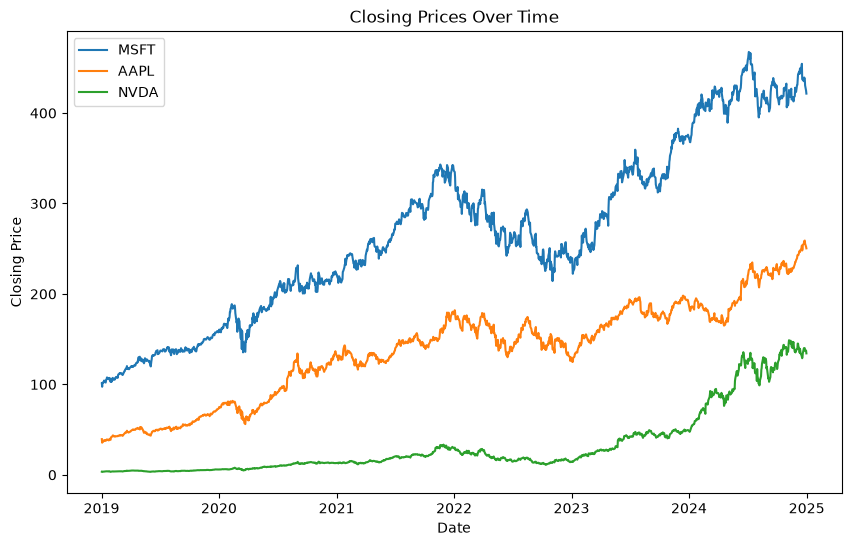

In [19]:
# Your code (C3)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for i in TICKERS:
    plt.plot(df.index, df['Close'][i], label=i)
plt.title('Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

**Your answer (C2):** the standard deviation of a stock's price is quoted constantly in finance.
Look at your three values. Is a stock with a larger price standard deviation necessarily a
riskier stock? Explain in one sentence. __No, higher price stck will _naturally show bigger dollar swring than a low std dev in price stock_

**Your answer (C3):** your chart plots three prices in dollars on one axis. One line probably
dominates the picture. Does that line belong to the stock that **grew** the most, or just the
stock with the **largest dollar price**? ___I believe its the one which has largest dollar price not necessarily the one that grew the most. ___

---
## Part D. Returns, and comparing things fairly  *(8 marks)*

Part C ended with a problem: a chart of dollar prices tells you which stock is expensive, not
which stock was a good investment. This part fixes that.

**D1.** *(2)* Compute the **daily percentage return** for each stock and store it in a DataFrame
called `returns`. Remember what you learned in A5.

**D2.** *(2)* Plot all three stocks **indexed to 100** on the first day, on one axis
(`100 * close / close.iloc[0]`). Compare this chart with your C3 chart.

**D3.** *(2)* Work out what \$10,000 invested in each stock on the first day of your data would
have been worth on the last day. Print the final value and the return as a percentage for each.

**D4.** *(2)* Convert each of those returns into an **annualised** figure (CAGR), using

$$\text{CAGR} = \left(\frac{P_{\text{end}}}{P_{\text{start}}}\right)^{1/n} - 1$$

where $n$ is the number of years.

In [20]:
# Your code (D1)
returns = close.pct_change()


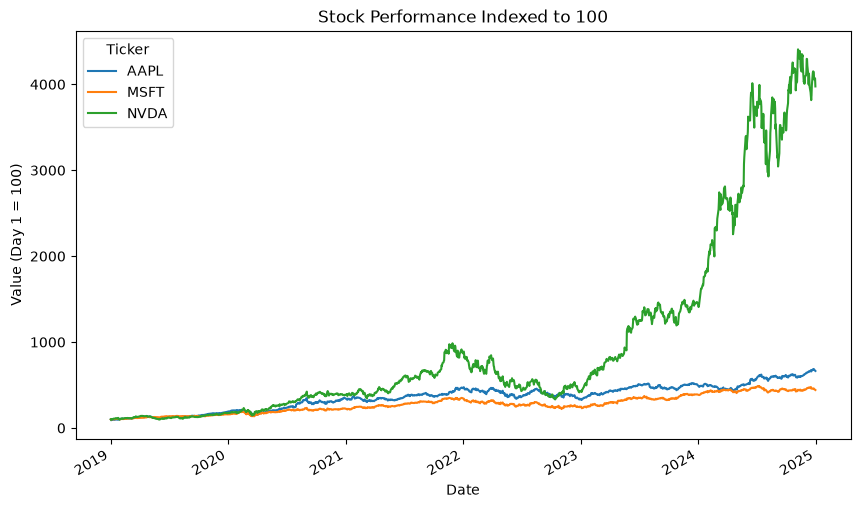

In [ ]:
# Your code (D2)
indexed = 100 * close / close.iloc[0]
indexed.plot(figsize=(10, 6))
plt.title('Stock Performance Indexed to 100')
plt.xlabel('Date')
plt.ylabel('Value (Day 1 = 100)')
plt.legend(title='Ticker')
plt.show()


In [21]:
# Your code (D3)
initial_investment = 10000
final_value = initial_investment * (close.iloc[-1] / close.iloc[0])
total_return_pct = (close.iloc[-1] / close.iloc[0] - 1) * 100

for ticker in ['AAPL', 'MSFT', 'NVDA']:
    print(f"{ticker}: Final value = ${final_value[ticker]:.2f}, Return = {total_return_pct[ticker]:.2f}%")


AAPL: Final value = $63429.58, Return = 534.30%
MSFT: Final value = $41683.15, Return = 316.83%
NVDA: Final value = $394332.68, Return = 3843.33%


In [22]:
# Your code (D4)
n_years = (close.index[-1] - close.index[0]).days / 365.25
cagr = (close.iloc[-1] / close.iloc[0]) ** (1 / n_years) - 1

for ticker in ['AAPL', 'MSFT', 'NVDA']:
    print(f"{ticker}: CAGR = {cagr[ticker] * 100:.2f}%")
   

AAPL: CAGR = 36.08%
MSFT: CAGR = 26.88%
NVDA: CAGR = 84.57%


**Your answer (D2):** which chart, C3 or D2, would you use to answer "which of these three was
the best investment", and why is the other one the wrong tool for that question? ___Id definitely use D2 because it shows growth failry, taking equal starting point. C3 simply shows raw dollars prices thats not a right measure because stock will definitely look bigger which has a higher price ___

**Your answer (D3):** for one of your stocks, write out both sentences and say which is correct:

- "\$10,000 became \$__$66,410____ , so the return was ___564%___%"
- "\$10,000 became \$___66410___ , so the investment grew to ___664%___% of what I put in"

These two numbers are not the same and confusing them is the most common error in this
assignment. ___First one is right for describing return 564%___Second one is correct for describing total value 664% stock gained, means how extra value my money gained

**Your answer (D4):** your six-year total returns look enormous. Do the annualised figures look
as impressive? Which number would you put in front of an investor, and which one would a person
selling you a fund put in front of you? ___Annualised figure look far less impressive than accumalated 6yr, but still its a strong return. As CAGR no. is the fair way to compare in different time periods.___

---
## Part E. Moving averages and slicing time  *(7 marks)*

**E1.** *(2)* Add a **50-day moving average** of the closing price for Apple, and plot it on the
same axes as the Apple closing price.

**E2.** *(2)* Using date slicing on the index, plot **only** Apple's closing price for calendar
year 2020. You do not need to filter rows by hand:
`close.loc['2020-01-01':'2020-12-31']` will do it.

**E3.** *(3)* Resample the Apple closing price to **monthly** frequency, taking the last closing
price of each month, and plot the monthly series over the daily one.

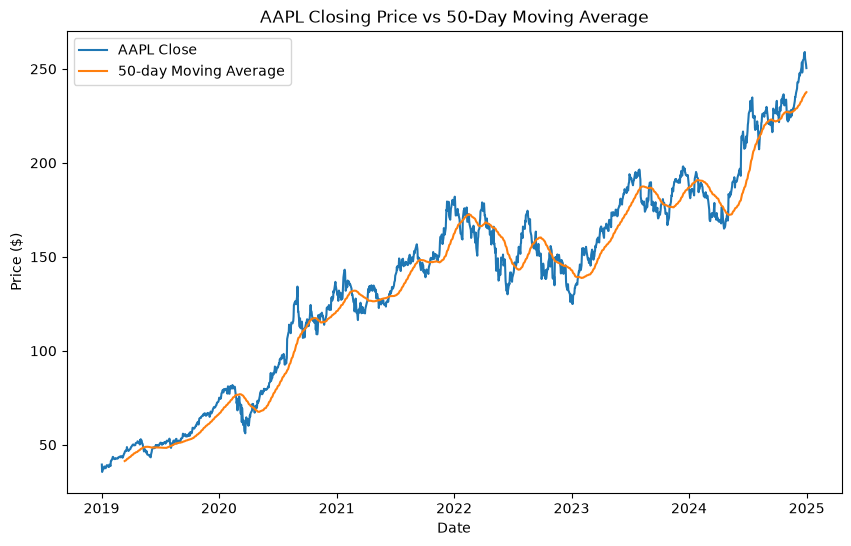

In [ ]:
# Your code (E1)

close['AAPL_MA50'] = close['AAPL'].rolling(window=50).mean()

plt.figure(figsize=(10, 6))
plt.plot(close.index, close['AAPL'], label='AAPL Close')
plt.plot(close.index, close['AAPL_MA50'], label='50-day Moving Average')
plt.title('AAPL Closing Price vs 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()


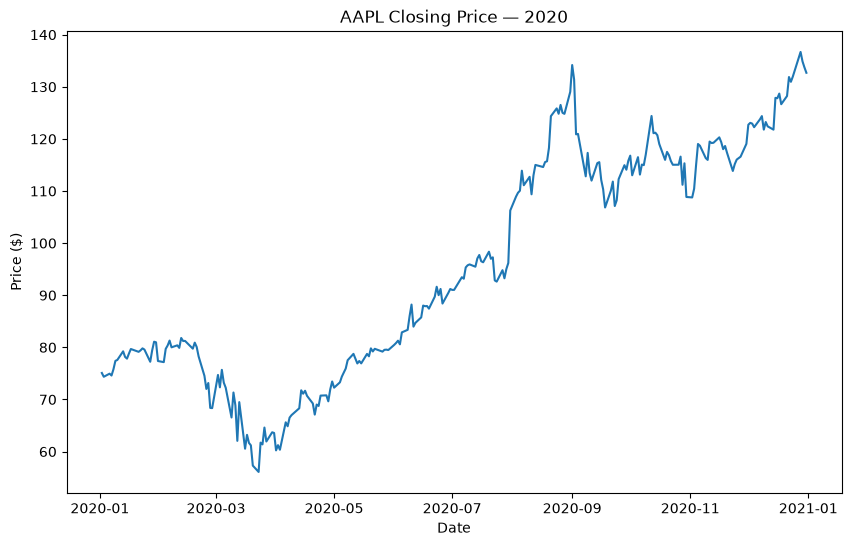

In [ ]:
# Your code (E2)

apple_2020 = close.loc['2020-01-01':'2020-12-31', 'AAPL']

plt.figure(figsize=(10, 6))
plt.plot(apple_2020.index, apple_2020)
plt.title('AAPL Closing Price — 2020')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()


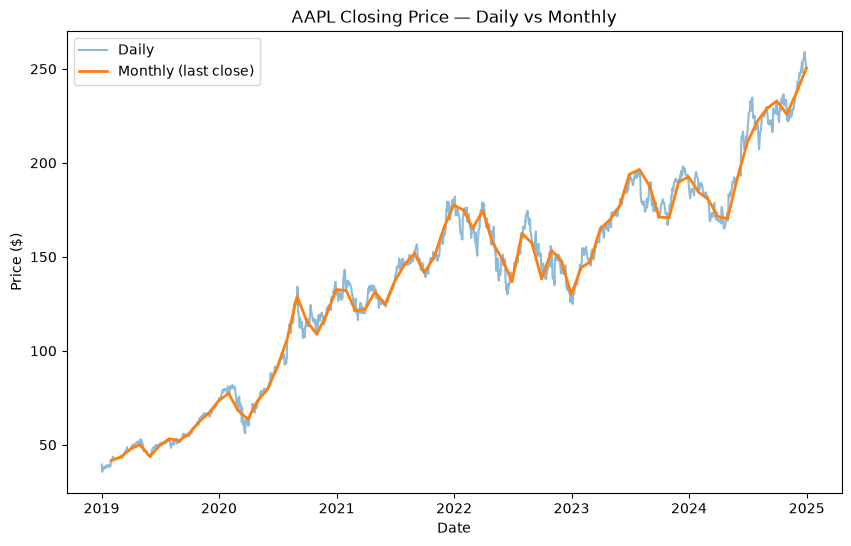

In [26]:
# Your code (E3)

monthly_aapl = close['AAPL'].resample('ME').last()

plt.figure(figsize=(10, 6))
plt.plot(close.index, close['AAPL'], label='Daily', alpha=0.5)
plt.plot(monthly_aapl.index, monthly_aapl, label='Monthly (last close)', linewidth=2)
plt.title('AAPL Closing Price — Daily vs Monthly')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()


**Your answer (E1):** the first 49 values of your moving average column are empty. Why, and what
would happen to a chart that quietly dropped those rows? ___Because it requires 50days of history first. If chart silentrly dropped those rows, MA line would look like it started later than its actual price line which definitely create confusionss___

**Your answer (E3):** the monthly line is smoother than the daily one. Name one thing the
monthly line hides that a manager might need to know about. _Volatility the most imp factor, sharp oneday drops or spikes within the month disappear because only the last day price survived._____

---
## Part F. Price and volume on one chart  *(7 marks)*

Trading volume runs into the hundreds of millions of shares. Prices run in the hundreds of
dollars. Putting both on one chart is the standard finance picture, and you met the problem it
creates in the last session.

**F1.** *(2)* Plot Apple's closing price and Apple's trading volume on **one ordinary axis**.
Describe what happened.

**F2.** *(3)* Now redo it with `ax2 = ax.twinx()`, price as a line on the left axis and volume as
bars on the right, each axis coloured to match its series.

**F3.** *(2)* Compute the actual correlation between Apple's daily return and its daily volume.

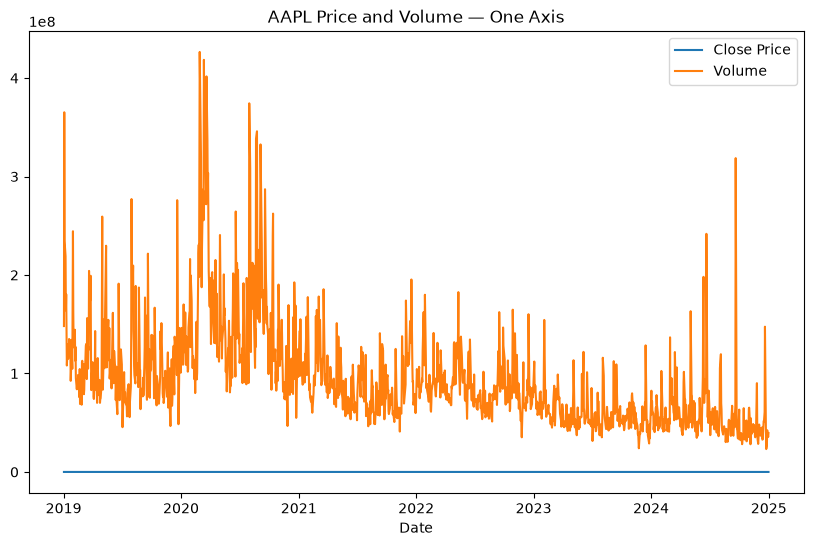

In [27]:
# Your code (F1)
plt.figure(figsize=(10, 6))
plt.plot(close.index, close['AAPL'], label='Close Price')
plt.plot(df.index, df['Volume']['AAPL'], label='Volume')
plt.title('AAPL Price and Volume — One Axis')
plt.xlabel('Date')
plt.legend()
plt.show()


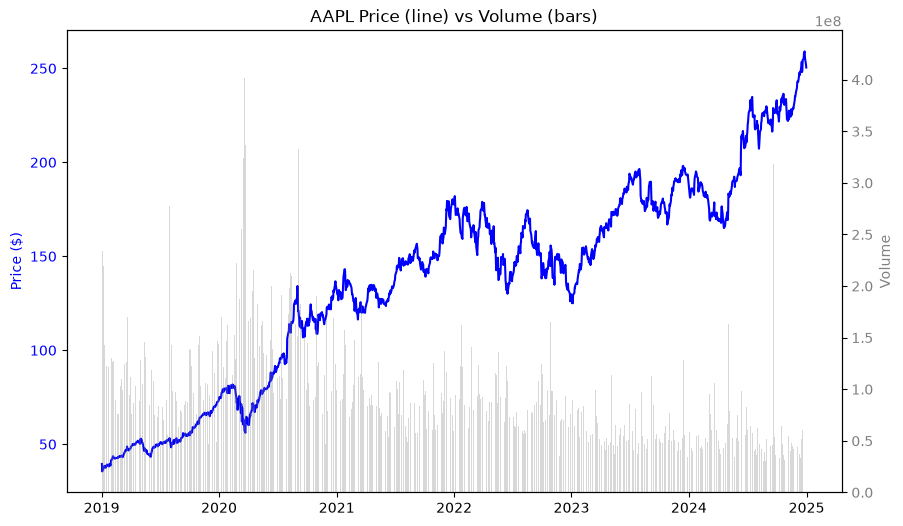

In [28]:
# Your code (F2)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(close.index, close['AAPL'], color='blue', label='Close Price')
ax.set_ylabel('Price ($)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

ax2 = ax.twinx()
ax2.bar(df.index, df['Volume']['AAPL'], color='gray', alpha=0.3, label='Volume')
ax2.set_ylabel('Volume', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.title('AAPL Price (line) vs Volume (bars)')
plt.show()


In [ ]:
# F3
r = returns['AAPL'].corr(df['Volume']['AAPL'])
print('correlation between daily return and volume: r =', round(r, 3))

r_abs = returns['AAPL'].abs().corr(df['Volume']['AAPL'])
print('correlation between SIZE of daily move and volume: r =', round(r_abs, 3))

correlation between daily return and volume: r = -0.021
correlation between SIZE of daily move and volume: r = 0.54


**Your answer (F1):** on one shared axis the price line looked like ___flat line___ because _volume's scale is much larger than price scale that the axis had to stretch to fit volume crushing price line flat_____

**Your answer (F3):** the two correlations above are quite different. The first asks whether
volume goes with the **direction** of the move, the second whether it goes with the **size** of
the move. Which one is larger, and what does that tell you about what heavy trading days
actually look like? ___Second > first one, it tells us that heavy trading days driven by big price swing in general in any case up/down. Traders react to volatility itself not just good news___

**Your answer (F3, part 2):** your twinx chart in F2 might suggest price and volume move
together. Does the correlation you just computed support that? If the chart and the number
disagree, which one do you trust? __No, it Number doesnt support fully. twinx chart can look like two series move together simply because each axis is scaled independently to fits its own data, creating a misleading visual in alignment. when chart and number disagree id trust correlation no.____

---
## Part G. Fix the machine's work  *(4 marks)*

The cell below was produced by an AI assistant, asked for
*"work out the return on \$10,000 invested in Apple at the start of 2019 and held to the end of
2024."*

It runs. It prints a number. The number is wrong, and it is wrong in a way that makes the
investment look **better** than it was.

1. Run it and note the answer.
2. Find at least one defect. There are two.
3. Fix it and print the correct figure.

In [43]:
# AI generated. Do not edit this cell.
data = yf.download('AAPL', start='2019-01-01', end='2024-12-31',
                   auto_adjust=True, progress=False)

start_price = data['Close'].iloc[0]
end_price   = data['Close'].max()          #  <-- read this line carefully

final_value = 10000 * (end_price / start_price)
print('Final value of $10,000:', round(float(final_value), 2))


TypeError: float() argument must be a string or a real number, not 'Series'

In [ ]:
# Your code (G): find the defects and print the correct figure

#  end='2025-01-01' instead of '2024-12-31', so 31 Dec 2024 is actually included
data = yf.download('AAPL', start='2019-01-01', end='2025-01-01',
                   auto_adjust=True, progress=False)

start_price = data['Close']['AAPL'].iloc[0]
#  .iloc[-1] instead of .max(), to get the actual final price, not the historical peak
end_price   = data['Close']['AAPL'].iloc[-1]

final_value = 10000 * (end_price / start_price)
print('Corrected final value of $10,000:', round(float(final_value), 2))



Corrected final value of $10,000: 66409.27


**Your answer (G):**

- The AI's answer was \$__its appearing an error____ . The correct answer is \$___66409.27___ .
- Defect 1: __end='2025-01-01' instead of '2024-12-31', so 31 Dec 2024 is actually included____
- Defect 2: ___.iloc[-1] instead of .max(), to get the actual final price, not the historical peak___
- Both defects push the answer in the same direction, which is ____upward, both making invst look better than actually performed__ . Why is that worse than
  an error that could go either way? ___1 directional bias is worse because it doesnt just add random noise it consistently and perdictably makes results look better than reality every time which could lead someone to systematically overestimate return and make bad invst decision with wrong confidence.___

---
## Part H. Before you start the assignment  *(not marked, but required)*

**No code. Close the laptop lid.**

Your assignment asks you to compare Microsoft, Apple and Nvidia from 1 January 2000 to
31 December 2024, and to end with *"recommendations or insights for potential investors"*.

Answer these three in four or five sentences total.

1. **The date.** 1 January 2000 was a Saturday. What will `yfinance` actually give you as the
   first row, and does it matter for your ROI calculation?

2. **The tickers.** Somebody chose Microsoft, Apple and Nvidia for you. Think about *when* that
   choice was made, and what you already know about how those three companies did. If you ran
   the same analysis on three large technology companies chosen in January 2000 **without
   knowing the future**, would you expect the same result? Name the problem this creates.

3. **The recommendation.** Your assignment asks you to advise potential investors on the basis
   of what these three stocks did between 2000 and 2024. State plainly whether that is something
   this analysis can support, and if not, what it *can* honestly tell an investor.

*Everything else in this lab, a machine can do for you. This one, it cannot, and question 2 is
the one your assignment will be marked hardest on.*

**Your answer (H):**
1. yfinace will start from the next trading day from 3jan 2000, since market were closed so this tiny shift barely affect the ROI

2. Microsoft, Apple, and Nvidia were picked with 25 years of hindsight, already knowing theyd succeed.But plenty of other "big tech" bets from 2000 looked just as promising and never recovered. This is survivorship bias, and it makes tech investing look far safer and more rewarding than it actually was for someone choosing blind at the time.

3. No, the analysis cant honestly tell an investor pick tech stocks like these and youll succeed, since that requires picking without knowing the future. What it can honestly show is how compounding and growth played out for these three specific, already-successful companies a historical case study, not investment advice.
*(type here)*

---
### Before you submit

- Every chart has a title and labelled axes
- Every **Your answer** cell has something typed in it
- Part A predictions were written before the cells were run
- Part H was answered without running code
- You saved `stocks_backup.csv` so you can redo this at home if Yahoo stops answering
- The file is renamed `S5Lab_YourRollNumber.ipynb`